# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,log_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-3.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,3.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,7.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40294699,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,-7.0,5.301710e+06,4785.274568,1.033029,0.699693,4.443421,0.0,20.0,20.0,-16.5584,0.011805,0.620124,0.003393,-0.219734,3.349485,2.651243,0.000388,0.002393
40294829,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,-3.5,5.301713e+06,4774.147852,1.051387,0.738442,4.468303,0.0,20.0,20.0,-16.0096,0.011805,0.620124,0.003484,-0.219734,3.349485,2.651243,0.000386,0.002387
40294959,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,5.301527e+06,5335.602998,1.127647,0.828561,4.480013,0.0,20.0,20.0,-16.2128,0.011804,0.620117,0.004141,-0.219722,3.349485,2.651243,0.000479,0.002668
40295089,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,3.5,5.301358e+06,5848.705172,1.211327,0.943752,4.515282,0.0,20.0,20.0,-16.0560,0.011803,0.620110,0.004882,-0.219711,3.349485,2.651243,0.000564,0.002924


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

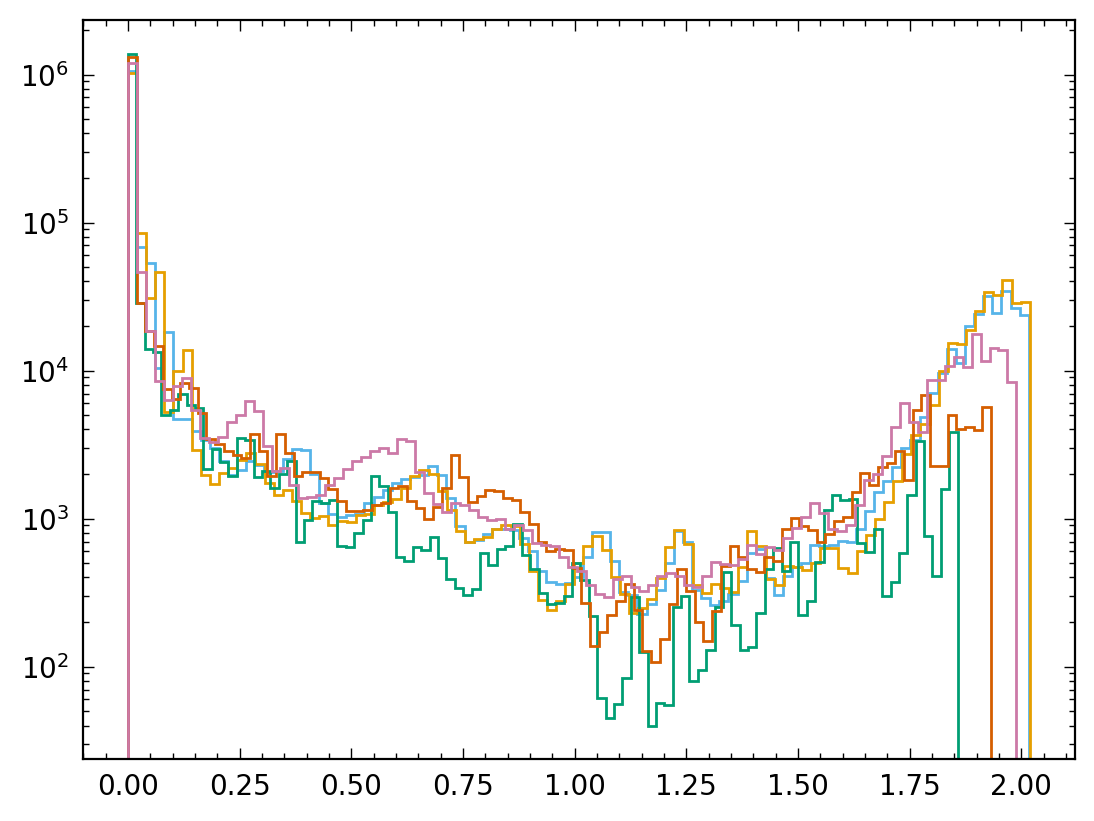

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-26.795884,0.771016,0.620211,2.157685
1,-6.698971,1.455869,0.620211,2.175863
2,0.700124,0.094770,0.870450,1.641856
3,0.717337,0.126711,0.961822,1.633700
4,0.735609,0.156570,1.036996,1.612346
...,...,...,...,...
100,2.677607,2.185883,1.194227,1.638715
101,2.813581,2.306246,1.154059,1.706882
102,3.349485,0.011810,0.620211,2.048877
103,5.359177,0.062590,0.620211,2.059304


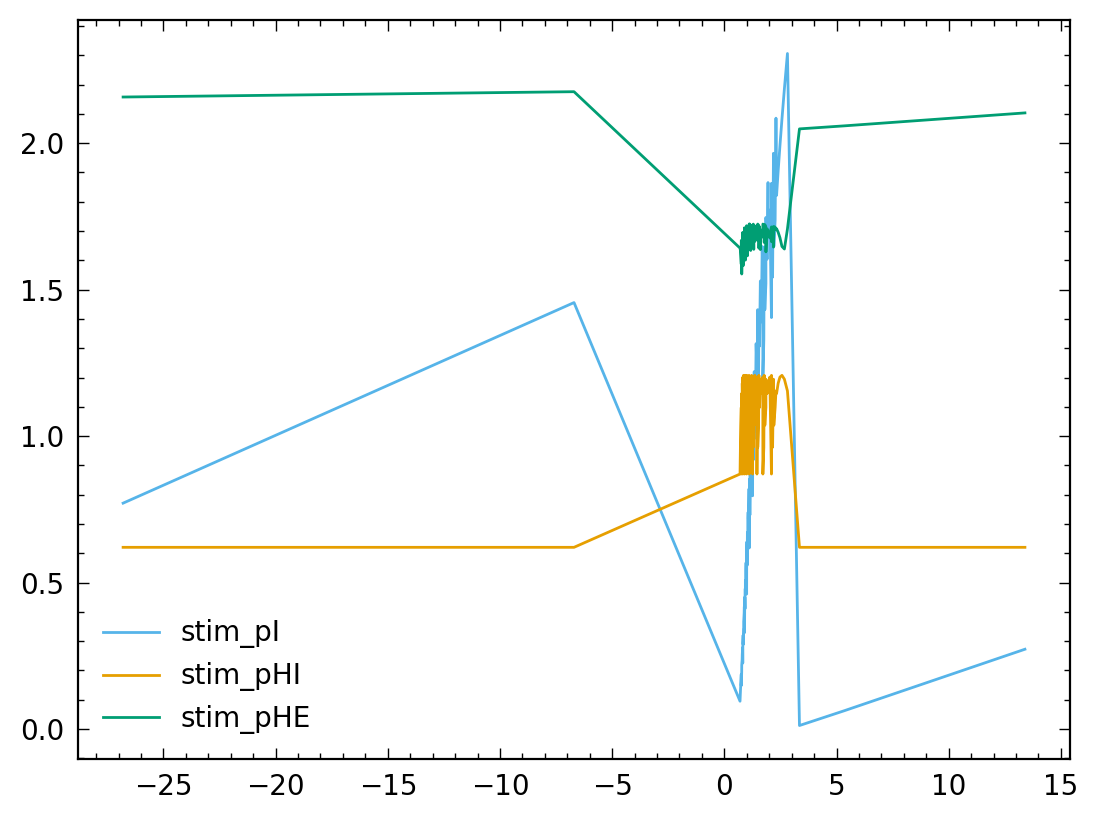

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 1050
fevals: 950
fevals: 24
fevals: 380


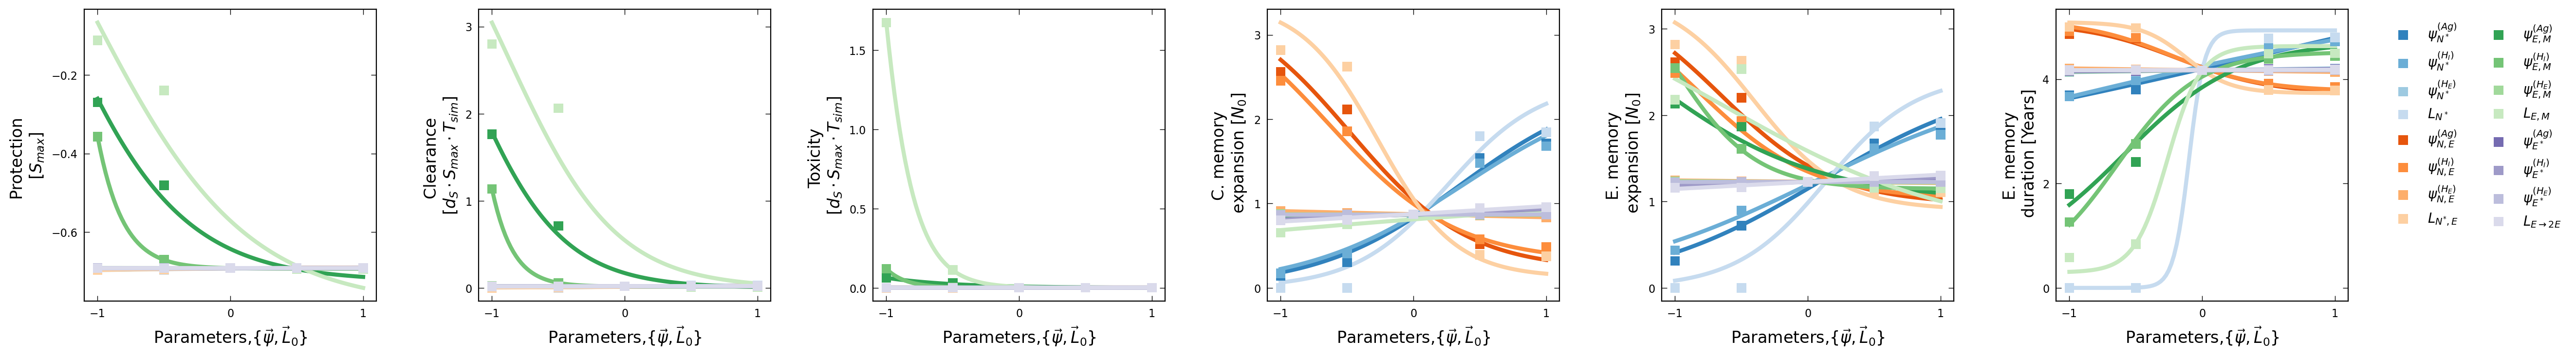

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    data = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[zero_regs]), axis = 1) == 0.0)]
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.loc[(np.sum(np.abs(data[reg_choice]), axis = 1) == np.abs(data[reg_choice[j]]))].groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
# del data

fevals: 14
fevals: 45
fevals: 12
fevals: 10
fevals: 10
fevals: 14
fevals: 34
fevals: 15
fevals: 42
fevals: 21
fevals: 25
fevals: 11
fevals: 10
fevals: 18
fevals: 23
fevals: 8


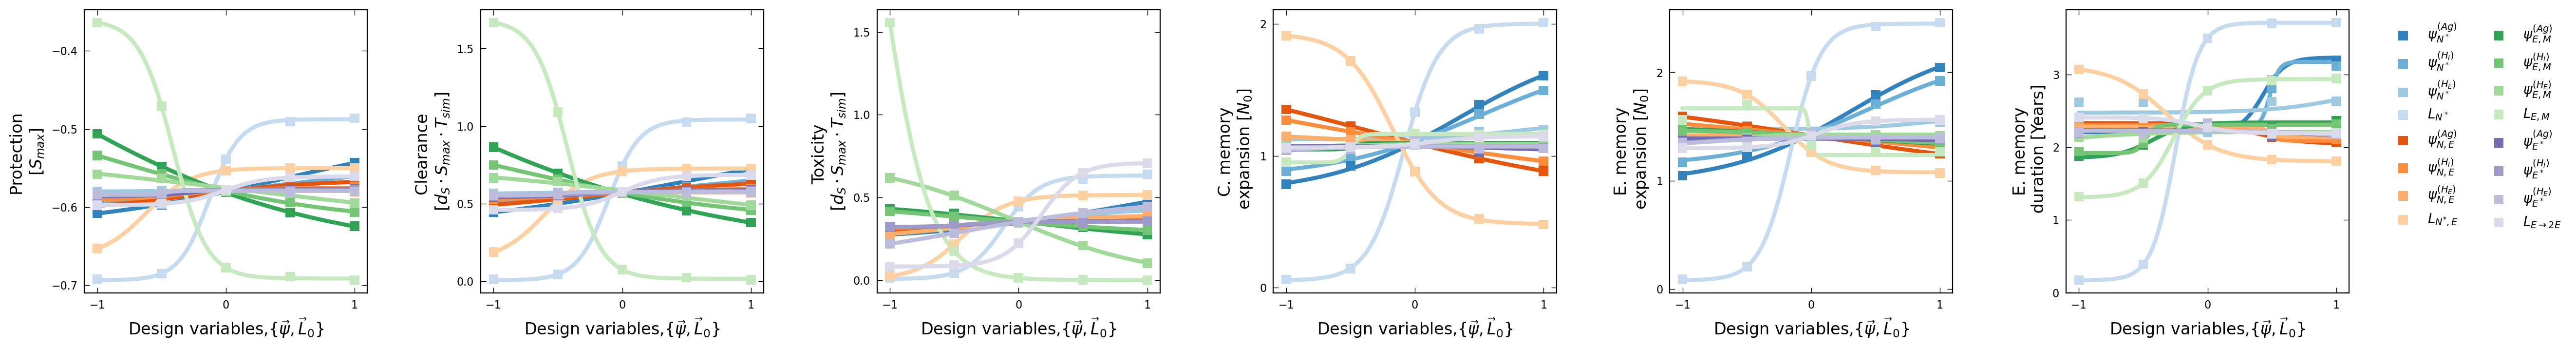

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 134
variables = reg
tol = 1e-6

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([np.minimum(0,(y_max - y_min)/2), np.minimum(0.0, 5*y_min)] + len(variables)*[-3.0*L0_max] + num_modules*[-3.0*L0_max], 
                                     [(1.01 if perf not in ["T_eM_min", "log_min_pS"] else 1.0)*(y_max - y_min) + tol, y_max + tol] + len(variables)*[3.0*L0_max] + num_modules*[3.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# View result
perf_choice = 0 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
0,0.000683,-0.006005,-0.001466,-0.010057,-0.001957,-0.059420,0.043036,0.006483,-0.004162,-0.047967,0.012224,0.005657,0.117493,1.270695,-0.032845,-0.010973,-0.037827,-0.148170,2.901462,3.050301,11.196144,3.751284,0.000102,1.019450e-04,0.004906,0.004999,0.004908,0.006207,0.009111,0.005847,0.005790,0.008359,0.007120,0.007117,0.007408,0.119502,0.008033,0.007999,0.008054,0.005708,0.199379,0.250807,0.850987,0.174467,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,-0.005417,-0.005405,-0.006087,-0.005405,0.0,0.000063,0.000069,0.000000,0.040966,0.312423,0.040534,NaN
6,0.001961,-0.007103,-0.000918,-0.005321,-0.001926,-0.059522,0.023446,-0.005449,-0.003253,-0.052198,0.010637,0.005072,0.155898,1.261447,-0.024725,-0.012049,-0.056531,-0.142043,2.847008,2.999944,10.893087,3.495624,0.000234,2.338814e-04,0.005373,0.005401,0.005376,0.006747,0.007273,0.006340,0.006303,0.008726,0.006706,0.006703,0.007304,0.104074,0.007486,0.007471,0.007612,0.005363,0.182337,0.226661,0.738561,0.143040,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,-0.005447,-0.005405,-0.007365,-0.005405,0.0,0.000206,0.000228,0.000000,0.040964,0.312423,0.061358,NaN
12,0.004901,-0.009614,-0.000773,-0.003396,-0.002660,-0.060857,0.017806,-0.006999,-0.003349,-0.054091,0.009648,0.005606,0.194763,0.985383,-0.021609,-0.011388,-0.081366,-0.133974,2.807685,2.993321,8.852822,3.342765,0.000518,5.165291e-04,0.005418,0.005429,0.005424,0.006667,0.007063,0.006611,0.006545,0.008816,0.006394,0.006392,0.007394,0.037653,0.007028,0.007016,0.007358,0.005102,0.169543,0.215301,0.282162,0.128758,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,-0.005519,-0.005405,-0.010305,-0.005405,0.0,0.000534,0.000596,0.000000,0.040959,0.312423,0.088222,NaN
18,0.011515,-0.015216,-0.000842,-0.003127,-0.003772,-0.061750,0.015957,-0.007827,-0.004398,-0.055177,0.009552,0.006962,0.233547,0.773164,-0.019702,-0.011515,-0.109720,-0.129282,2.767402,2.968688,7.323469,3.246758,0.001128,1.125313e-03,0.005365,0.005373,0.005377,0.006516,0.006955,0.006651,0.006583,0.008702,0.006263,0.006262,0.007710,0.018356,0.006707,0.006699,0.007355,0.004894,0.161183,0.206630,0.157768,0.120869,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,-0.005688,-0.005405,-0.016919,-0.005405,0.0,0.001280,0.001432,0.000000,0.040948,0.312423,0.122296,NaN
24,0.025837,-0.027245,-0.000621,-0.002321,-0.004697,-0.061616,0.015003,-0.008390,-0.006064,-0.055548,0.009284,0.008427,0.269757,0.641902,-0.018337,-0.011513,-0.135470,-0.124059,2.722781,2.945635,6.382022,3.161137,0.002393,2.385807e-03,0.005251,0.005255,0.005270,0.006388,0.006880,0.006642,0.006590,0.008625,0.006151,0.006150,0.008064,0.012238,0.006405,0.006398,0.007455,0.004697,0.156150,0.201772,0.121655,0.115413,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,-0.006064,-0.005405,-0.031241,-0.005405,0.0,0.002901,0.003250,0.000000,0.040923,0.312423,0.164333,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,0.034615,-0.219827,0.237685,1.875777,0.362188,2.082675,0.099024,0.848588,0.252231,0.956598,-0.194564,-2.120323,-0.925025,-2.136891,0.117697,1.172720,0.520132,1.214553,1.12376

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

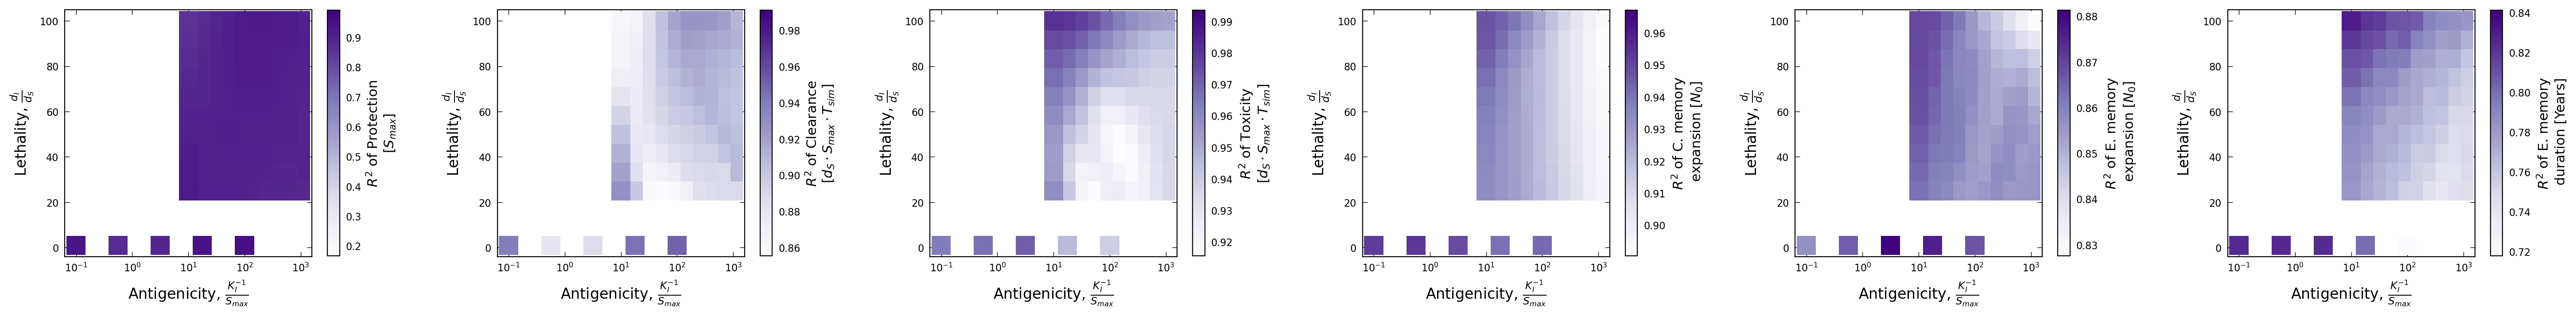

In [12]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 2750/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_r_sq = 1 - data.rmse**2/data.y_std**2
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

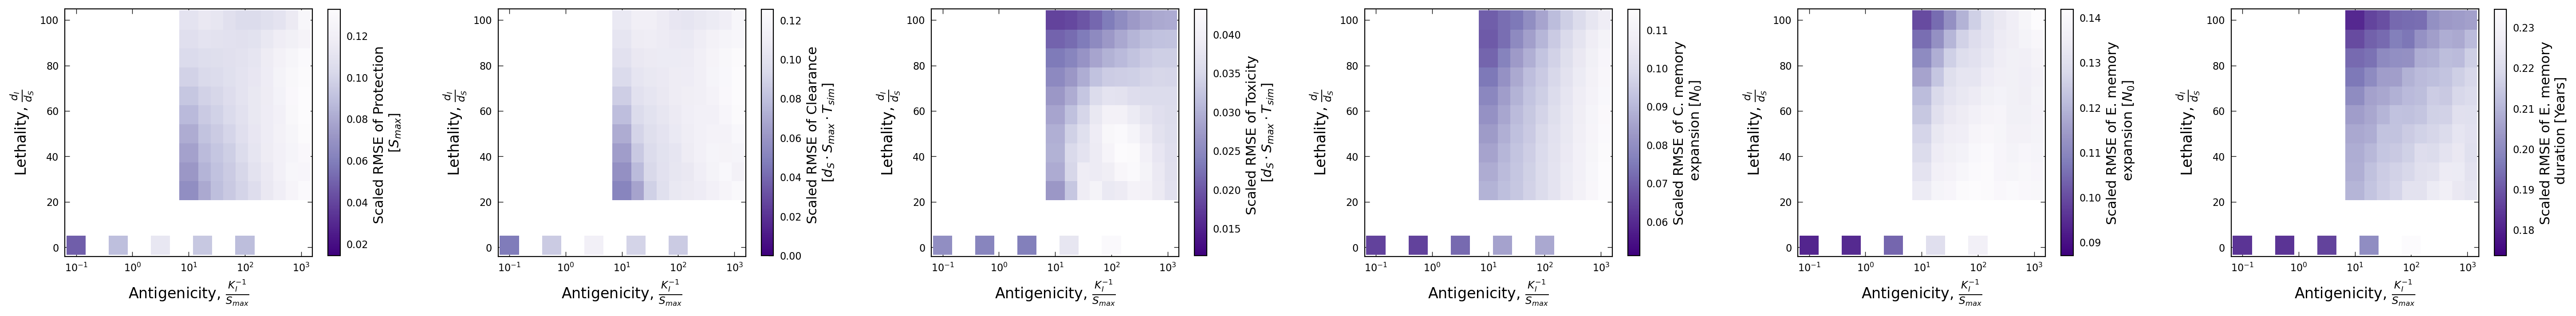

In [13]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_rmse_over_max = data.rmse/data.y_range
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

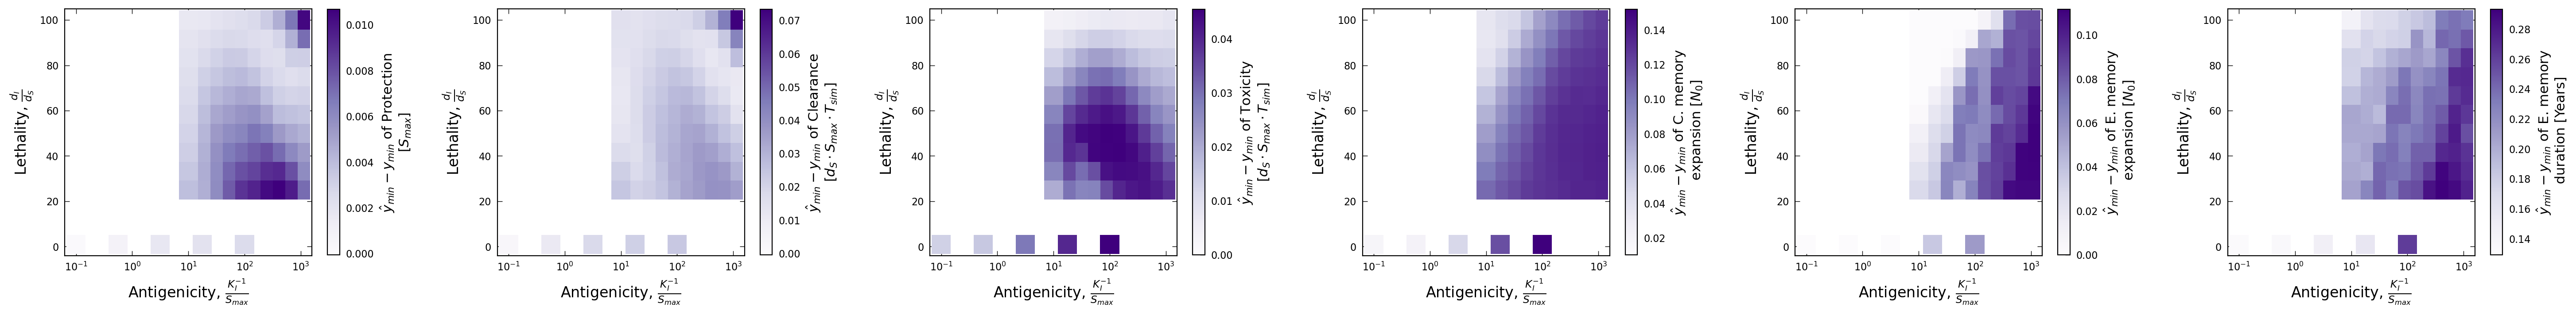

In [14]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, c = data.y_min - data.min_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

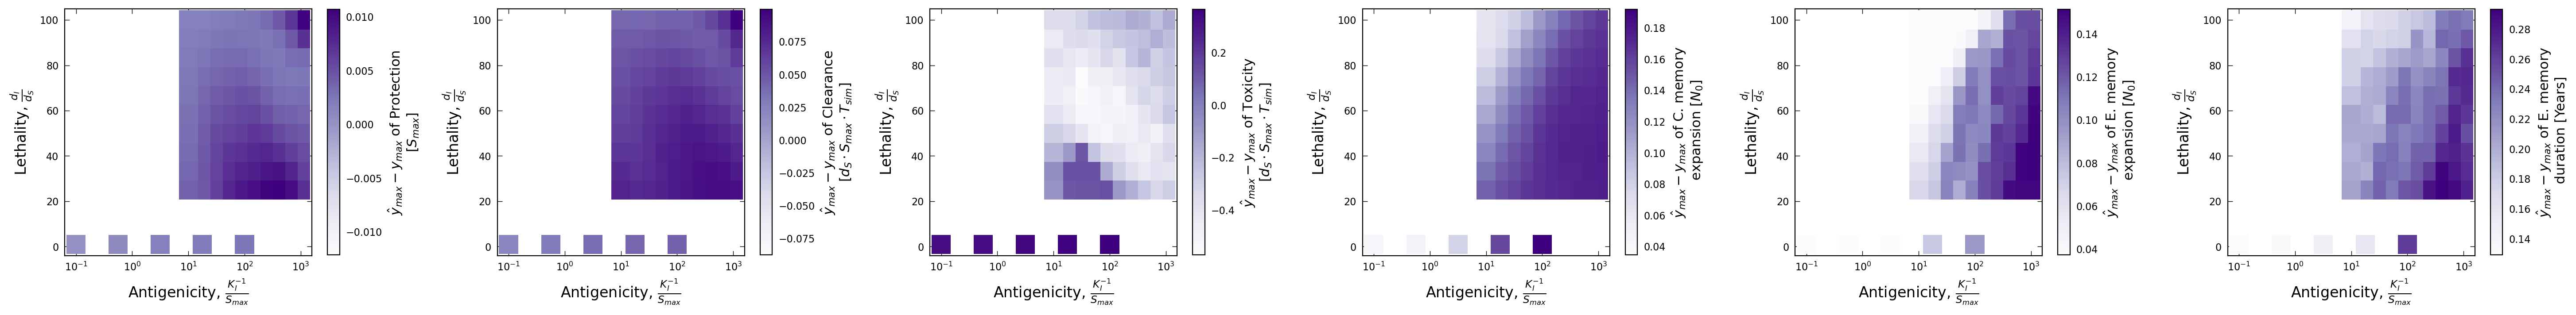

In [15]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, c = data.y_range + data.y_min - data.max_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

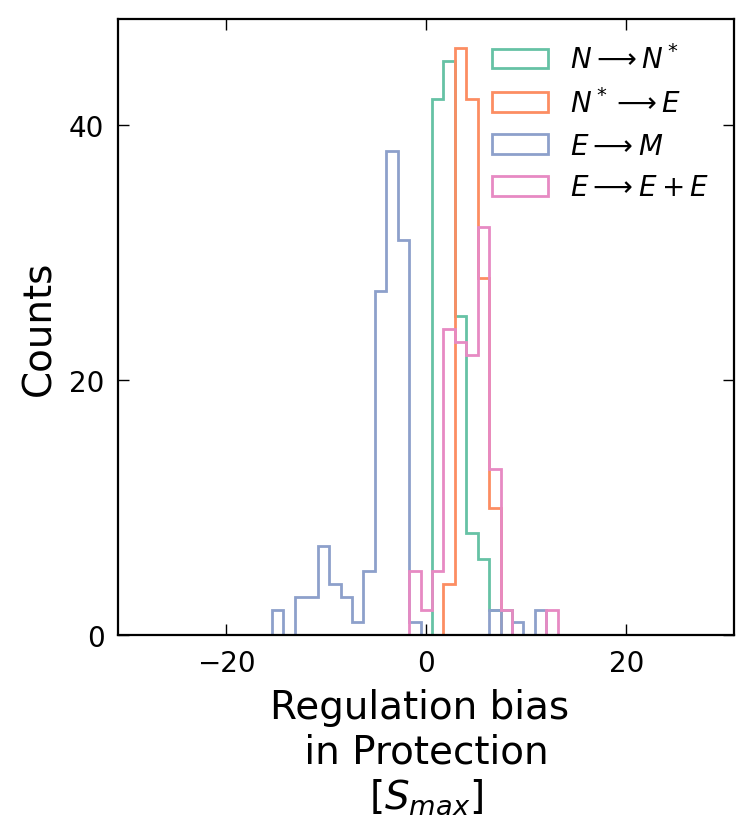

In [16]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-4*L0_max, 4*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

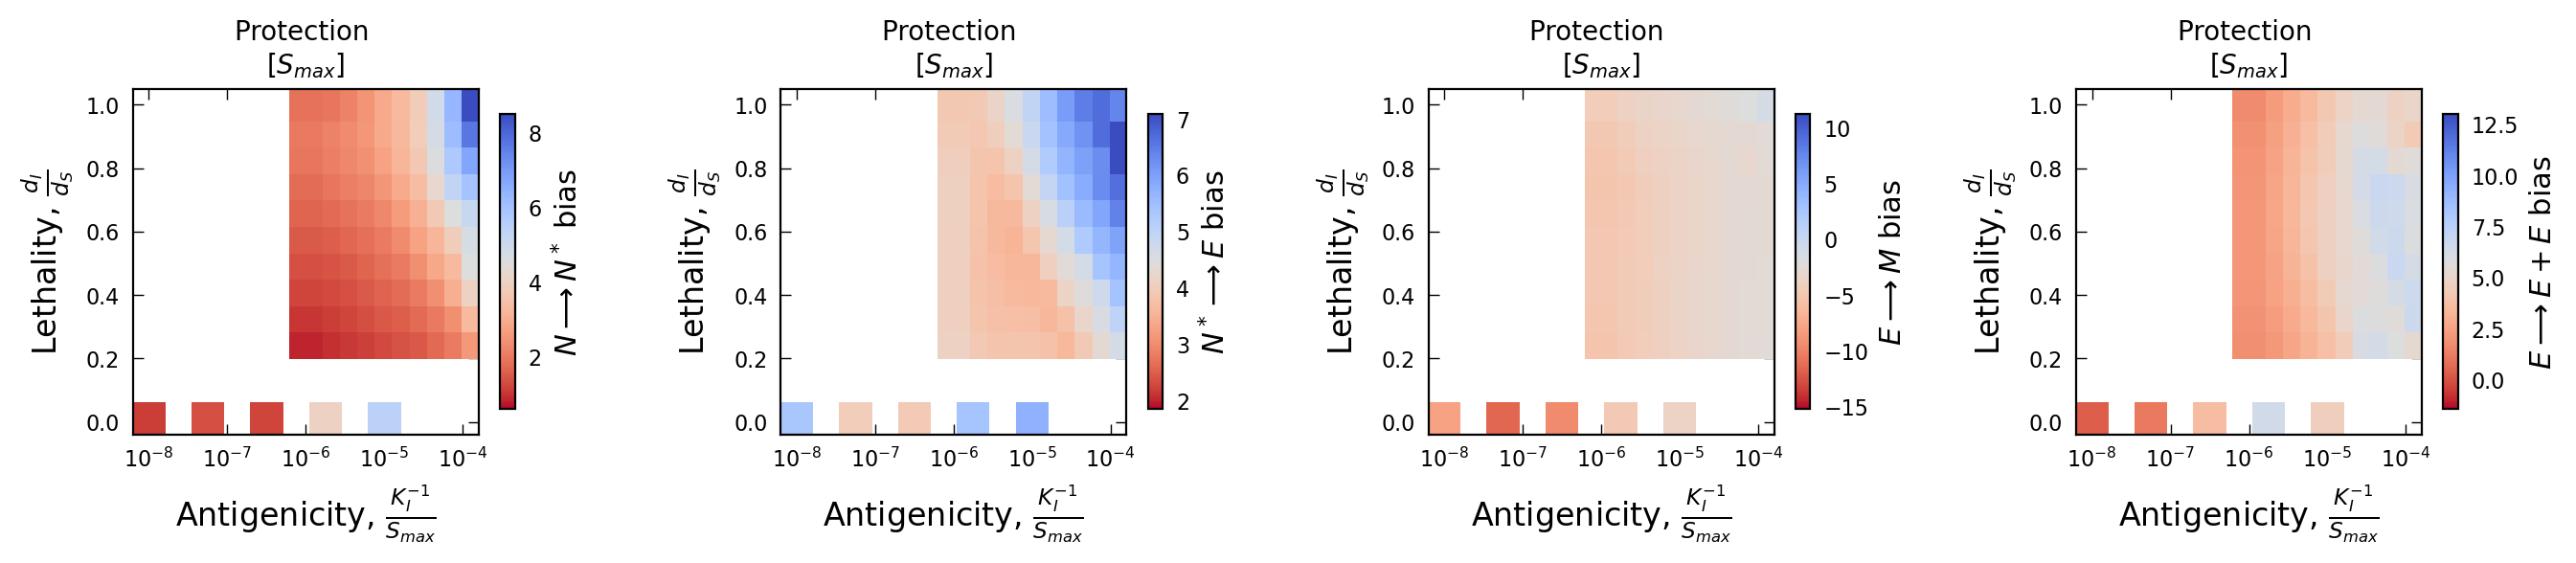

In [17]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

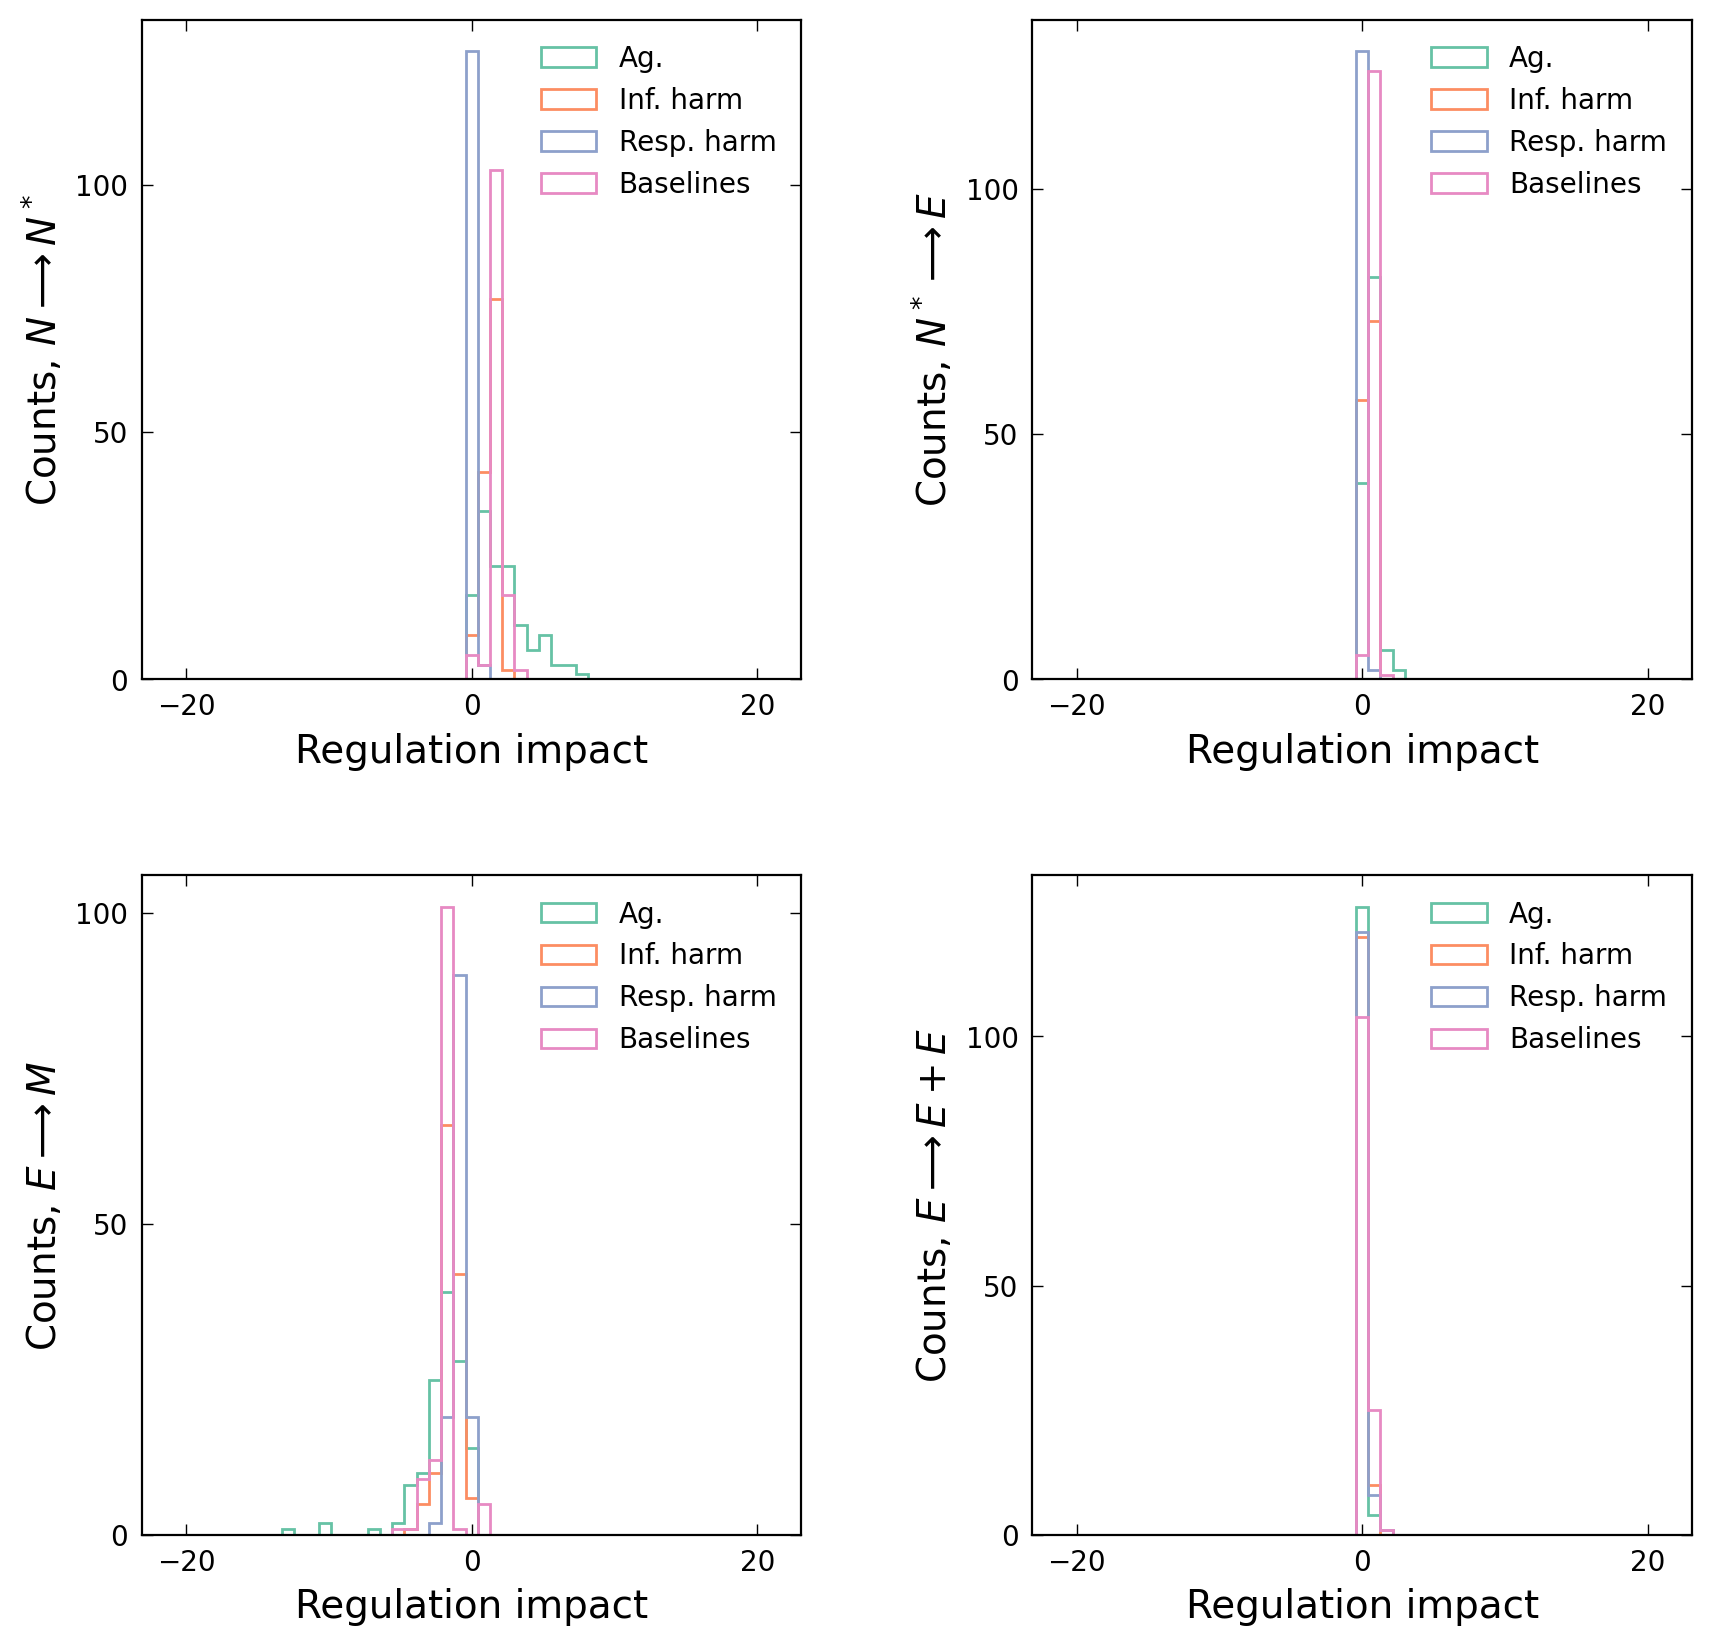

In [18]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*L0_max, 3.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
0,0.000683,-0.006005,-0.001466,-0.010057,-0.001957,-0.059420,0.043036,0.006483,-0.004162,-0.047967,0.012224,0.005657,0.117493,1.270695,-0.032845,-0.010973,-0.037827,-0.148170,2.901462,3.050301,11.196144,3.751284,0.000102,0.000102,0.004906,0.004999,0.004908,0.006207,0.009111,0.005847,0.005790,0.008359,0.007120,0.007117,0.007408,0.119502,0.008033,0.007999,0.008054,0.005708,0.199379,0.250807,0.850987,0.174467,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,-0.005417,-0.005405,-0.006087,-0.005405,0.0,0.000063,0.000069,0.0,0.040966,0.312423,0.040534,NaN
6,0.001961,-0.007103,-0.000918,-0.005321,-0.001926,-0.059522,0.023446,-0.005449,-0.003253,-0.052198,0.010637,0.005072,0.155898,1.261447,-0.024725,-0.012049,-0.056531,-0.142043,2.847008,2.999944,10.893087,3.495624,0.000234,0.000234,0.005373,0.005401,0.005376,0.006747,0.007273,0.006340,0.006303,0.008726,0.006706,0.006703,0.007304,0.104074,0.007486,0.007471,0.007612,0.005363,0.182337,0.226661,0.738561,0.143040,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,-0.005447,-0.005405,-0.007365,-0.005405,0.0,0.000206,0.000228,0.0,0.040964,0.312423,0.061358,NaN
12,0.004901,-0.009614,-0.000773,-0.003396,-0.002660,-0.060857,0.017806,-0.006999,-0.003349,-0.054091,0.009648,0.005606,0.194763,0.985383,-0.021609,-0.011388,-0.081366,-0.133974,2.807685,2.993321,8.852822,3.342765,0.000518,0.000517,0.005418,0.005429,0.005424,0.006667,0.007063,0.006611,0.006545,0.008816,0.006394,0.006392,0.007394,0.037653,0.007028,0.007016,0.007358,0.005102,0.169543,0.215301,0.282162,0.128758,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,-0.005519,-0.005405,-0.010305,-0.005405,0.0,0.000534,0.000596,0.0,0.040959,0.312423,0.088222,NaN
18,0.011515,-0.015216,-0.000842,-0.003127,-0.003772,-0.061750,0.015957,-0.007827,-0.004398,-0.055177,0.009552,0.006962,0.233547,0.773164,-0.019702,-0.011515,-0.109720,-0.129282,2.767402,2.968688,7.323469,3.246758,0.001128,0.001125,0.005365,0.005373,0.005377,0.006516,0.006955,0.006651,0.006583,0.008702,0.006263,0.006262,0.007710,0.018356,0.006707,0.006699,0.007355,0.004894,0.161183,0.206630,0.157768,0.120869,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,-0.005688,-0.005405,-0.016919,-0.005405,0.0,0.001280,0.001432,0.0,0.040948,0.312423,0.122296,NaN
24,0.025837,-0.027245,-0.000621,-0.002321,-0.004697,-0.061616,0.015003,-0.008390,-0.006064,-0.055548,0.009284,0.008427,0.269757,0.641902,-0.018337,-0.011513,-0.135470,-0.124059,2.722781,2.945635,6.382022,3.161137,0.002393,0.002386,0.005251,0.005255,0.005270,0.006388,0.006880,0.006642,0.006590,0.008625,0.006151,0.006150,0.008064,0.012238,0.006405,0.006398,0.007455,0.004697,0.156150,0.201772,0.121655,0.115413,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,-0.006064,-0.005405,-0.031241,-0.005405,0.0,0.002901,0.003250,0.0,0.040923,0.312423,0.164333,NaN


In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
630,0.200891,-0.219524,5.545063,1.660116,0.168799,1.995162,2.565145,0.735439,0.057376,1.017116,-9.932014,-3.062936,-1.606646,-3.637123,0.235272,0.069300,0.040122,0.351918,3.113591,5.998724,-13.030584,5.348696,0.000151,2.832574e-05,0.026071,0.009677,0.005931,0.009006,0.010929,0.006263,0.005680,0.003319,0.067730,0.021702,0.012168,0.025085,0.020385,0.020299,0.020269,0.017937,0.015373,0.021998,0.087827,0.132149,0.01,1.000000e+05,0.1,50000.0,100.000000,10000000.0,1000000.0,-0.191412,-0.018937,-0.219827,-0.219719,0.0,0.013605,0.063071,2.651243,1.352578,0.582340,0.158916,-6.698971
636,0.202815,-0.218615,5.438640,1.626566,0.221345,1.961471,1.730613,0.469631,0.053529,0.601838,-12.699665,-3.916604,-2.495214,-4.721849,0.535842,0.094310,0.033626,0.554829,3.028415,3.914323,-15.223247,7.856228,0.000177,4.153798e-05,0.031361,0.011659,0.007238,0.010863,0.009319,0.005971,0.005619,0.002608,0.094894,0.030850,0.020906,0.034736,0.054799,0.051419,0.050824,0.107143,0.018298,0.017523,0.120394,0.767069,0.01,1.000000e+05,0.1,50000.0,234.034732,10000000.0,1000000.0,-0.183563,-0.017013,-0.219827,-0.219581,0.0,0.019802,0.073151,2.651243,1.306565,0.569679,0.191286,-6.698971
642,0.204672,-0.218515,6.154953,1.866026,0.253960,2.200603,2.167564,0.601828,0.074144,0.738115,-10.291603,-3.036656,-2.072966,-3.850868,0.347836,0.112594,0.029225,0.957398,3.762073,5.336502,-11.369929,12.050055,0.000149,3.985747e-05,0.037376,0.012959,0.006686,0.012979,0.012580,0.006586,0.005778,0.004112,0.051554,0.017130,0.013048,0.018943,0.211765,0.210401,0.207675,1.654140,0.024239,0.028869,0.062531,11.632640,0.01,1.000000e+05,0.1,50000.0,547.722558,10000000.0,1000000.0,-0.178929,-0.015156,-0.219827,-0.219267,0.0,0.018928,0.078208,2.651243,1.272423,0.562193,0.233255,-6.698971
648,0.206499,-0.218144,6.960694,2.153465,0.292497,2.464735,2.062842,0.623229,0.081213,0.759995,-6.875752,-2.085129,-1.470670,-2.630447,0.243740,0.053048,-0.031306,0.951568,4.664651,5.709692,-6.816168,12.987381,0.000141,3.969443e-05,0.046302,0.015597,0.006834,0.016032,0.012451,0.006639,0.005678,0.004625,0.028770,0.010362,0.008138,0.010774,0.587781,0.589844,0.589206,4.300671,0.032658,0.032667,0.032043,30.242370,0.01,1.000000e+05,0.1,50000.0,1281.861019,10000000.0,1000000.0,-0.176217,-0.013329,-0.219827,-0.218533,0.0,0.018663,0.079889,2.651243,1.253496,0.559009,0.285698,-6.698971
654,0.208225,-0.217359,7.663123,2.392174,0.333989,2.698273,1.823102,0.541203,0.066368,0.733178,-4.744793,-1.424261,-1.144809,-1.810693,0.198855,0.036969,-0.319919,0.037449,5.452879,5.724676,-3.698278,4.530014,0.000854,4.118526e-05,0.053087,0.017670,0.007049,0.018353,0.010961,0.006276,0.005551,0.004644,0.016326,0.006488,0.005834,0.006007,0.061611,0.037473,0.094378,0.013982,0.039336,0.032940,0.014369,0.392784,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,-0.173240,-0.011577,-0.219827,-0.216815,0.0,0.018463,0.079965,2.651243,1.238411,0.555574,0.341706,-6.698971
660,0.200379,-0.219576,2.341171,1.447816,0.169685,1.724767,1.460746,0.916385,0.098810,1.191519,-4.388126,-2.850493,-1.486542,-3.419588,0.094213,0.065242,0.031029,0.334903,2.276357,6.570229,-12.949121,4.631684,0.000140,2.363625e-05,0.009226,0.006911,0.004932,0.005721,0.006345,0.005635,0.004899,0.003189,0.018714,0.012786,0.007454,0.014371,0.011589,0.011584,0.011578,0.008931,0.00768